# Amazon ML Challenge 2026: EXP-001 EDA

This notebook visualizes the results of the memory-conscious data audit (EXP-001) for the semantic business entity resolution task.

**Objective:** Provide an overview of dataset scale, missingness, distribution shifts, and match counts based entirely on the `exp001_data_audit.json` and `exp001_file_summary.csv` compact artifacts.

*Note: This notebook does not process the raw multi-GB dataset directly in order to adhere to memory limits. No ML pipelines, candidates, or models are trained here.*

In [1]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

# Determine repository root robustly relative to this notebook
repo_root = Path.cwd()
while not (repo_root / ".git").exists() and repo_root.parent != repo_root:
    repo_root = repo_root.parent
if not (repo_root / ".git").exists():
    repo_root = Path.cwd().parent

json_path = repo_root / "reports" / "exp001_data_audit.json"
csv_path = repo_root / "reports" / "exp001_file_summary.csv"

assert json_path.exists(), f"Missing {json_path}"
assert csv_path.exists(), f"Missing {csv_path}"

with open(json_path) as f:
    audit = json.load(f)

files = audit['files']
print(f"Successfully loaded {json_path.name}")
print(f"Files audited: {len(files)}")

Successfully loaded exp001_data_audit.json
Files audited: 7


## 1. Dataset Overview

To understand the scale of the challenge, we compare the total row count across all seven files (train, test, and ground truth).

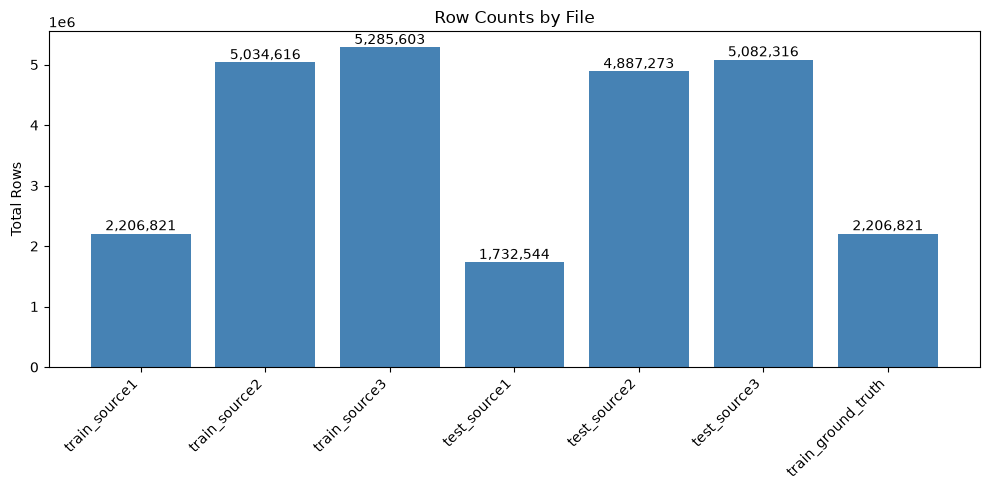

Total rows in source files (Train + Test): 24,229,173


In [2]:
names = list(files.keys())
counts = [f['total_rows'] for f in files.values()]

plt.figure(figsize=(10, 5))
bars = plt.bar(names, counts, color='steelblue')
plt.title('Row Counts by File')
plt.ylabel('Total Rows')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval):,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

total_rows = sum(counts[:6]) # Exclude ground truth to count source rows
print(f"Total rows in source files (Train + Test): {total_rows:,}")

**Interpretation:** Both train and test sets are massive, making memory-efficient processing (like streaming) mandatory. Sources 2 and 3 contain double the records of Source 1.

## 2. Country Distribution & Shift

We inspect the distribution of records by `country` to detect any domain shift between the training data and the unseen test set.

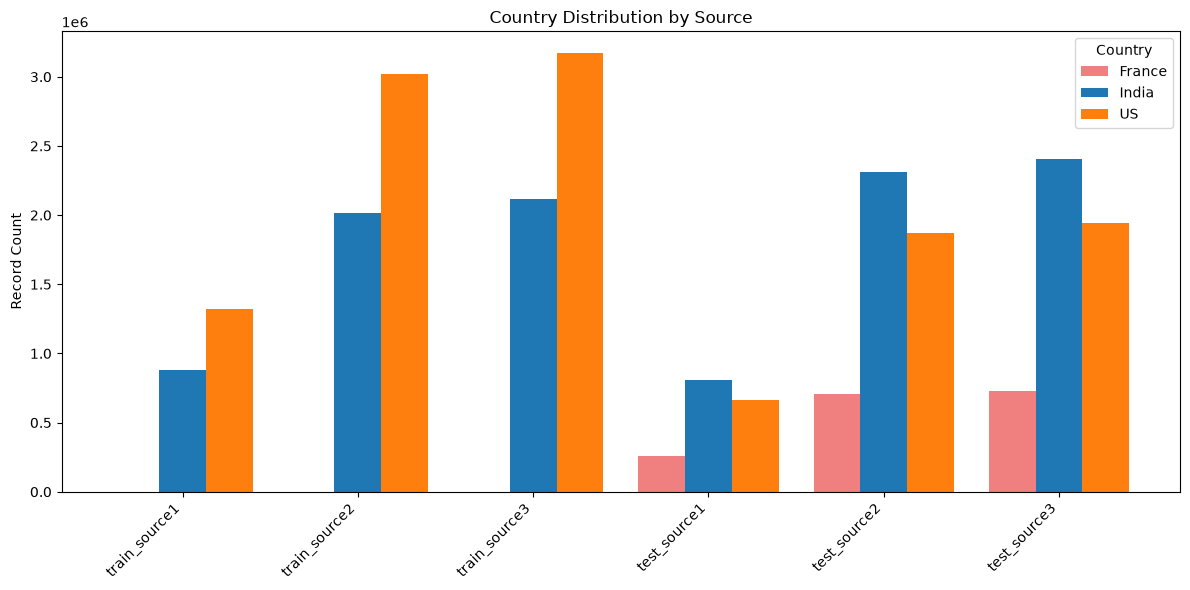

In [3]:
sources = [k for k in files.keys() if 'source' in k]

# Collect all unique countries across source files
countries = set()
for k in sources:
    countries.update(files[k].get('country_frequency', {}).keys())
countries = sorted(list(countries))

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(sources))
bar_width = 0.8 / len(countries)

for i, c in enumerate(countries):
    y = [files[k].get('country_frequency', {}).get(c, 0) for k in sources]
    # Color training countries vs unseen test country (France)
    color = 'lightcoral' if c == 'France' else None
    ax.bar([pos + i * bar_width for pos in x], y, bar_width, label=c, color=color)

ax.set_xticks([pos + bar_width for pos in x])
ax.set_xticklabels(sources, rotation=45, ha='right')
ax.set_title('Country Distribution by Source')
ax.set_ylabel('Record Count')
ax.legend(title='Country')

plt.tight_layout()
plt.show()

**Interpretation:** There is a significant distribution shift. The **training data** ONLY contains `US` (60%) and `India` (40%). However, the **test data** additionally contains `France` (~14-15%). 
*Implication:* Our blocking strategies and string similarity metrics must generalize well to unseen country data (such as French formatting), and we cannot hardcode logic strictly to US/India structures.

## 3. Missing-Address Analysis

Evaluating the completeness of string data is crucial before applying metrics. The audit indicated missing values only exist in `business_address`.

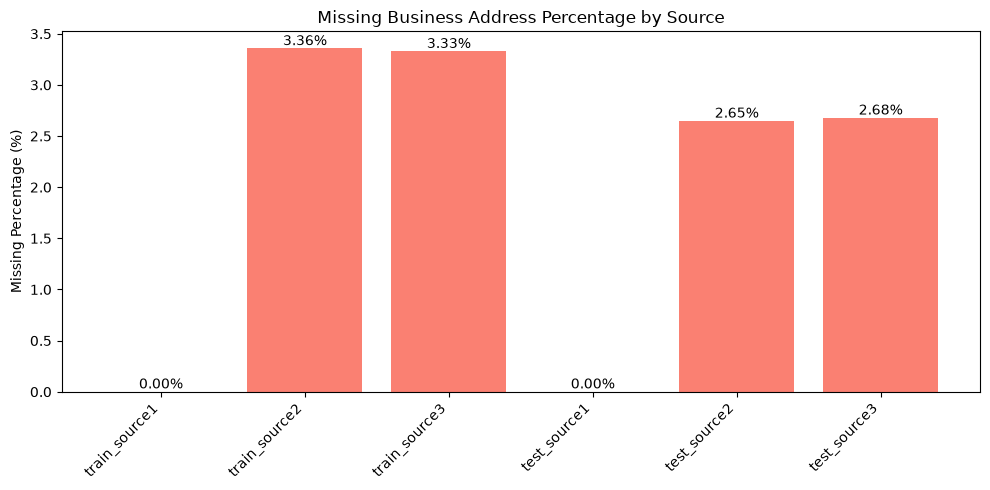

In [4]:
missing_pcts = []
for k in sources:
    total = files[k]['total_rows']
    nulls = files[k].get('empty_string_counts', {}).get('business_address', 0)
    missing_pcts.append((nulls / total) * 100)

plt.figure(figsize=(10, 5))
bars = plt.bar(sources, missing_pcts, color='salmon')
plt.title('Missing Business Address Percentage by Source')
plt.ylabel('Missing Percentage (%)')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Interpretation:** Addresses are completely populated in Source 1, but are missing for **~2.6% to 3.4%** of records in Sources 2 and 3. 
*Implication:* We cannot rely on `business_address` as a strictly universal blocking key or require it for all matches. Fallback mechanisms using `business_name` will be required for these incomplete records.

## 4. Business Name and Address Length Distributions

Understanding character lengths informs our blocking token sizes and string similarity parameter choices. Using the pre-calculated percentiles from the audit, we visualize the length ranges.

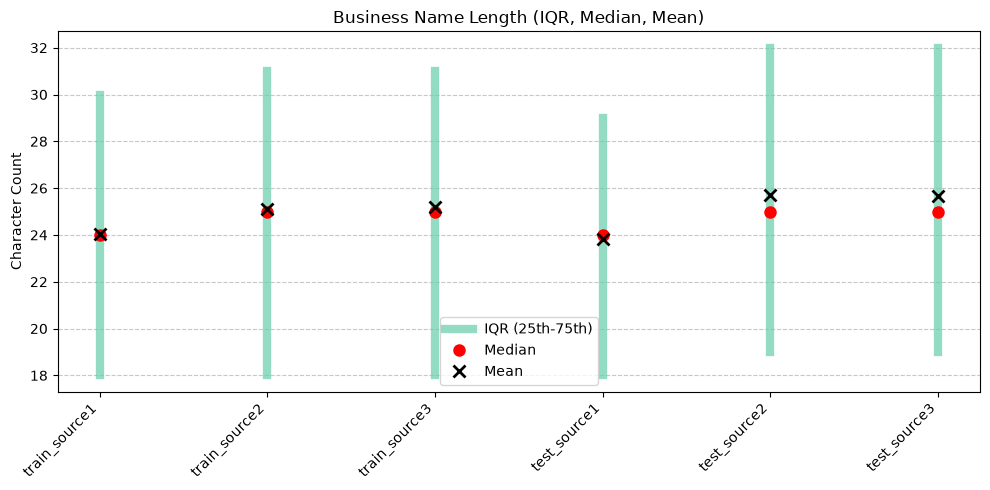

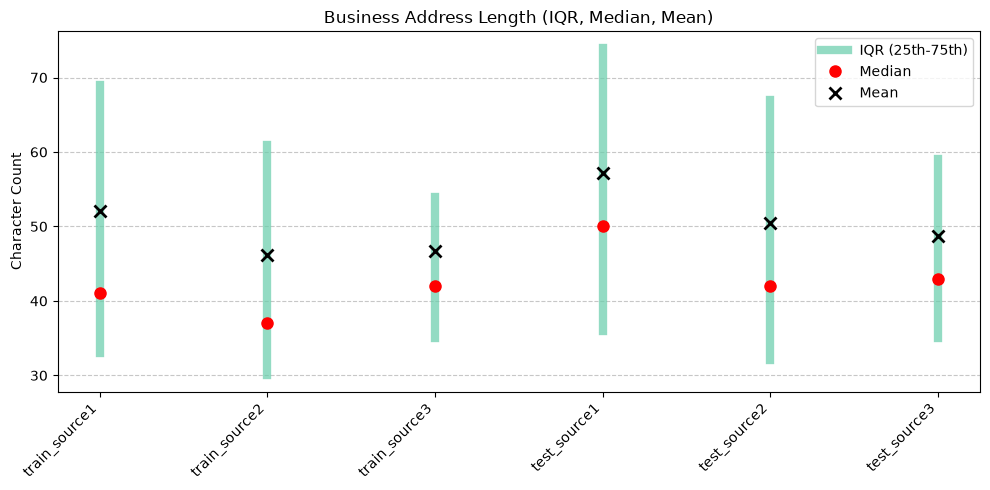

In [5]:
def plot_length_stats(field, title):
    plt.figure(figsize=(10, 5))
    
    for i, k in enumerate(sources):
        stats = files[k].get(field)
        if not stats:
            continue
        
        p25 = stats.get('p25', stats.get('mean'))  # fallback
        p75 = stats.get('p75', stats.get('mean'))
        p50 = stats.get('p50', stats.get('median', stats.get('mean')))
        mean = stats.get('mean')
        
        # Plot IQR as a thick line
        plt.plot([i, i], [p25, p75], color='mediumaquamarine', lw=6, alpha=0.7, label='IQR (25th-75th)' if i==0 else "")
        # Plot Median
        plt.plot(i, p50, 'ro', markersize=8, label='Median' if i==0 else "")
        # Plot Mean
        plt.plot(i, mean, 'kx', markersize=8, markeredgewidth=2, label='Mean' if i==0 else "")
        
    plt.xticks(range(len(sources)), sources, rotation=45, ha='right')
    plt.title(title)
    plt.ylabel('Character Count')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_length_stats('business_name_length', 'Business Name Length (IQR, Median, Mean)')
plot_length_stats('business_address_length', 'Business Address Length (IQR, Median, Mean)')

**Interpretation:**
- **Business Names** are typically concise, tightly grouped around 20-30 characters across all sources.
- **Business Addresses** are much wider and more varied, typically centering around 40-50 characters but showing substantially higher variance indicating differing granularities.

## 5. Ground Reality: Match-Count Distribution

This is highly critical: we analyze the `train_ground_truth.tsv` to see how many S2/S3 matches a single S1 instance maps to.

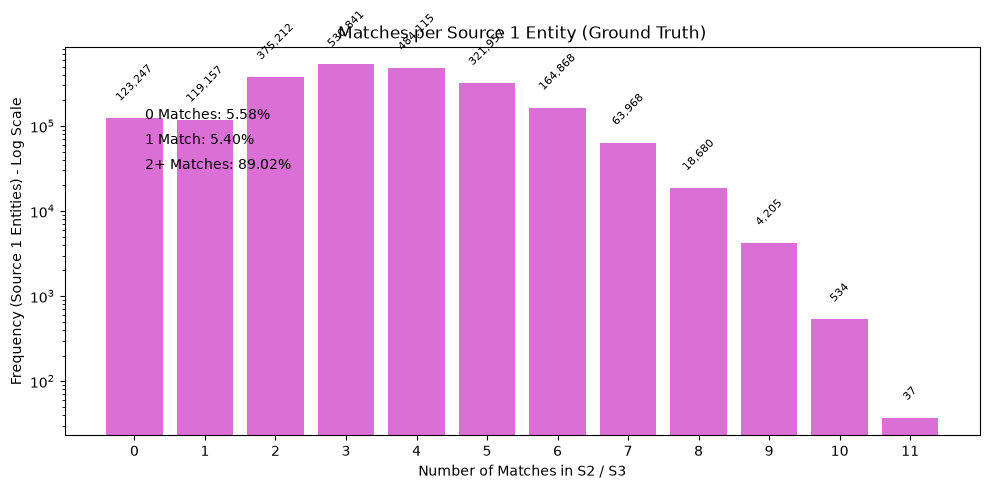

In [6]:
gt = files.get('train_ground_truth', {})
dist = gt.get('match_count_distribution', {})

# Convert string keys to int and sort
if dist:
    x_vals = sorted([int(k) for k in dist.keys()])
    y_vals = [dist[str(x)] for x in x_vals]
    
    plt.figure(figsize=(10, 5))
    bars = plt.bar(x_vals, y_vals, color='orchid')
    plt.title('Matches per Source 1 Entity (Ground Truth)')
    plt.xlabel('Number of Matches in S2 / S3')
    plt.ylabel('Frequency (Source 1 Entities) - Log Scale')
    plt.xticks(x_vals)
    plt.yscale('log')  # Log scale for visibility given the dominance of lower counts
    
    # Add value labels slightly above
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval * 1.5, f'{int(yval):,}', ha='center', va='bottom', fontsize=8, rotation=45)
        
    # Annotate key figures
    total_s1 = sum(y_vals)
    zero_pct = (dist.get('0', 0) / total_s1) * 100
    one_pct = (dist.get('1', 0) / total_s1) * 100
    multi_pct = 100 - zero_pct - one_pct
    
    plt.figtext(0.15, 0.75, f"0 Matches: {zero_pct:.2f}%", fontsize=10)
    plt.figtext(0.15, 0.70, f"1 Match: {one_pct:.2f}%", fontsize=10)
    plt.figtext(0.15, 0.65, f"2+ Matches: {multi_pct:.2f}%", fontsize=10)
    
    plt.tight_layout()
    plt.show()

**Interpretation of the 1-to-Many Match Problem:**
- **0 matches (Singletons)**: ~123,247 cases (5.58%). It is valid for an entity to NOT exist in the other sources.
- **1 match (1-to-1)**: ~119,157 cases (5.40%).
- **Multi-matches**: The overwhelming majority of the problem (89.02%) entails tracking down up to 11 matches per S1 entity.
*Implication:* Classical 1-to-1 deduplication strategies (like stable marriage assignment) will forcefully drop up to 90% of the true matches. We must frame this as a 1-to-many retrieval task.

## 6. Key EDA Findings & Implications

Based *only* on the measured EXP-001 audit results, the following facts significantly constrain our pipeline design:

1. **Dataset Scale is Severe:** At 26+ million rows / 2.35 GB, we cannot ever join or cross-product the data natively in memory (our RAM limit is ~7.1 GiB). Blocking is strictly required.
2. **Address Missingness:** `business_address` drops roughly 3% of the time in sources 2 & 3. It cannot be used as a hard requirement for a match rule.
3. **Country Distribution Shift:** A new country code, `France` (~14%), appears entirely unrepresented in the training phase. The matching features must rely on generalization rather than domain-specific token dictionaries (e.g., US zip codes).
4. **Dominance of 1-to-Many Links:** 89% of instances map to multiple downstream IDs (up to 11). Standard assignment solvers applied symmetrically are not appropriate here; scoring thresholds mapping over sets is the reality.
5. **High Data Cleanliness:** No duplicates, null values in unexpected columns, or malformed prefixes were found. This completely eliminates the need for basic ID sanitation.